## Logistic Regression for imbalanced dataset

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline 

In [3]:
#generate and plot syntetic imbalanced classification dataset

from collections import Counter
from sklearn.datasets import make_classification

In [4]:
#imbalanced dataset

X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)

In [5]:
X

array([[ 1.87991016, -1.4850347 ],
       [ 0.37708311, -2.23858488],
       [ 1.35431163, -2.66463822],
       ...,
       [ 0.99509904, -0.54192355],
       [ 1.75859359, -1.54961188],
       [ 0.79770543, -1.99467372]], shape=(10000, 2))

In [7]:
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

<Axes: xlabel='0', ylabel='1'>

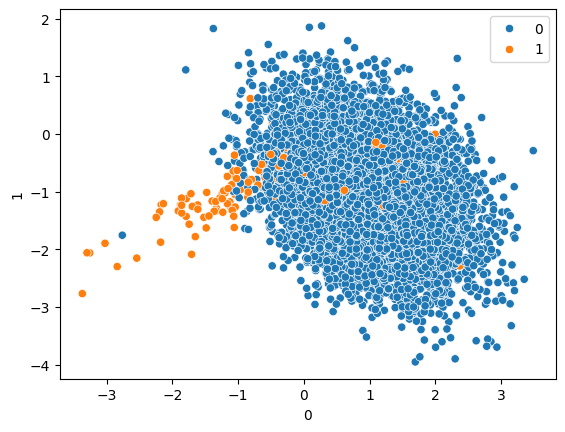

In [9]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [10]:
#split the data into train test and split 

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.25,random_state=0)

In [ ]:
#hyperparameter tuning

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.001]
solver=['newton-cg','lbfgs', 'libliner','sag','saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
#last line is used to define various class weight so this is one of the imp lines

In [19]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)

In [20]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.001],
 'solver': ['newton-cg', 'lbfgs', 'libliner', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [21]:
from sklearn.model_selection import  GridSearchCV
from sklearn.model_selection import  StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)

In [22]:
grid.fit(X_train,y_train)

/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached w

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [23]:
grid.best_params_

{'C': 100, 'class_weight': {0: 1, 1: 10}, 'penalty': 'l1', 'solver': 'saga'}

In [24]:
y_pred=grid.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [26]:
score = accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_pred,y_test))

0.9892
[[7372   12]
 [  69   47]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      7384
           1       0.80      0.41      0.54       116

    accuracy                           0.99      7500
   macro avg       0.89      0.70      0.77      7500
weighted avg       0.99      0.99      0.99      7500

[[7372   69]
 [  12   47]]
